# Online Classification

Summary of the best test accuracies from the expand-and-sparsify pipeline
across both datasets.

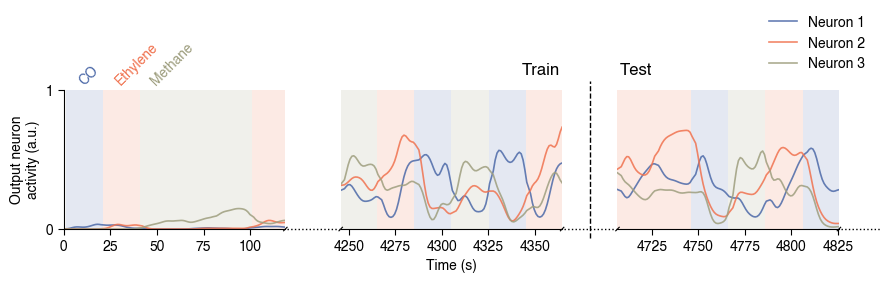

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from scipy.ndimage import gaussian_filter1d
from tools import load, whiten, estimate_derivative
import sklearn.metrics

# ── colour map ──
cm = ListedColormap(plt.rcParams['axes.prop_cycle'].by_key()['color'])

# ── load & preprocess (same as Classification.ipynb cell 8) ──
rng = np.random.default_rng(42)

n_hd = 10000
n_out = 3
k = 200
p = 0.005
p_w_hd = 0.05
n_train = 450

filename = '1_600_20'
sensor_data, sequence, times_sec, sequence_sec = load(filename, reduced=True)
d_sensor_data = np.apply_along_axis(estimate_derivative, axis=0, arr=sensor_data)
sensor_data = np.hstack((sensor_data, d_sensor_data))
sensor_data = whiten(sensor_data)

x_dense = sensor_data
n_dense = x_dense.shape[1]

labels = np.zeros_like(times_sec)
for i, t in enumerate(sequence_sec[:n_train]):
    try:
        flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i+1])
    except IndexError:
        flag = (times_sec > sequence_sec[i])
    labels[flag] = int(sequence[i][1])

idx_last_flag = np.where(labels != 0)[0][-1]

W_hd = np.random.binomial(n=1, p=p_w_hd, size=(n_hd, n_dense))
x_hd = x_dense @ W_hd.T
ranks = np.argsort(np.argsort(-x_hd, axis=1), axis=1)
z_hd = np.where(ranks < k, 1., 0.)
W_out = np.zeros((n_out, n_hd))

z_out_train = np.zeros((z_hd.shape[0], n_out))
for i, row in enumerate(z_hd[:idx_last_flag]):
    if labels[i] != 0:
        active_idx = np.flatnonzero(row)
        to_flip = active_idx[rng.random(active_idx.size) < p]
        W_out[int(labels[i])-1, to_flip] = 1./k
    z_out_train[i] = row @ W_out.T

z_out_acc = np.zeros((z_hd.shape[0], n_out))
for i, row in enumerate(z_hd):
    z_out_acc[i] = row @ W_out.T

z_out = np.empty((z_hd.shape[0], n_out))
z_out[:idx_last_flag] = z_out_train[:idx_last_flag]
z_out[idx_last_flag:] = z_out_acc[idx_last_flag:]

# ── top-row config ──
top_intervals_idx = [(0, 6), (212, 218)]
j0, j1 = 235, 241
max_len = 20
sigma = 2.
connector_color = 'black'
connector_lw = 1.
connector_ls = ':'
slash_color = 'black'
slash_lw = 0.8
slash_len_fig = 0.02
slash_angle_deg = 80
slash_inset = 0.003

colour = np.zeros_like(times_sec, dtype=int)
for i in range(len(sequence_sec)):
    t_start = sequence_sec[i]
    t_end = sequence_sec[i + 1] if i + 1 < len(sequence_sec) else np.inf
    mask = (times_sec >= t_start) & (times_sec < t_end)
    colour[mask] = int(sequence[i][1])

# ── helpers ──
def seq_idx_window_to_sample_idx(a_idx, b_idx):
    a_idx = int(np.clip(a_idx, 0, len(sequence_sec) - 1))
    b_idx = int(np.clip(b_idx, 0, len(sequence_sec) - 1))
    t0 = int(np.abs(times_sec - sequence_sec[a_idx]).argmin())
    t1 = int(np.abs(times_sec - sequence_sec[b_idx]).argmin())
    if t1 <= t0:
        t1 = min(t0 + 1, len(times_sec))
    return t0, t1

def find_blocks(labels, max_len=20, ignore=0):
    labels = np.asarray(labels)
    n = len(labels)
    if n == 0: return []
    blocks, start, prev = [], 0, labels[0]
    for i in range(1, n + 1):
        cur = labels[i] if i < n else None
        if cur != prev:
            if prev != ignore:
                s = start
                while s < i:
                    e = min(s + max_len, i)
                    blocks.append((s, e, int(prev)))
                    s = e
            start, prev = i, cur
    return blocks

def block_edges_from_indices(x, s, e):
    L = x[0] if s <= 0 else 0.5 * (x[s-1] + x[s])
    R = x[-1] if e >= len(x) else 0.5 * (x[e-1] + x[e])
    return L, R

# ── windows ──
t0_a, t1_a = seq_idx_window_to_sample_idx(*top_intervals_idx[0])
t0_b, t1_b = seq_idx_window_to_sample_idx(*top_intervals_idx[1])
t0_test, t1_test = seq_idx_window_to_sample_idx(j0, j1)
x0_ref = times_sec[t0_a]

# ── figure: top row only ──
fig = plt.figure(figsize=(10, 1.8))
gs_top = GridSpec(1, 3, figure=fig, wspace=0.25)
ax_l = fig.add_subplot(gs_top[0, 0])
ax_m = fig.add_subplot(gs_top[0, 1])
ax_r = fig.add_subplot(gs_top[0, 2])

def plot_interval_time_x(ah, t0, t1, title=None, pos=None, hide_y=False):
    x_raw = times_sec[t0:t1]
    x = x_raw - x0_ref
    labels_local = colour[t0:t1]
    blocks = find_blocks(labels_local, max_len=max_len)
    for i in range(z_out.shape[1]):
        smoothed = gaussian_filter1d(z_out[t0:t1, i], sigma=sigma)
        ah.plot(x, smoothed, label=f'Neuron {i+1}', color=cm(i % cm.N), linewidth=1.2, alpha=0.85)
    for s, e, lab in blocks:
        if lab == 0: continue
        L, R = block_edges_from_indices(x, s, e)
        if R > L:
            ah.axvspan(L, R, facecolor=cm((lab-1) % cm.N), alpha=0.15, linewidth=0)
    ah.set_xlim(x[0], x[-1])
    ah.set_ylim(0., 1.)
    if not hide_y:
        ah.set_yticks([0, 1])
    else:
        ah.set_yticks([])
        ah.set_ylabel("")
        ah.spines['left'].set_visible(False)
    if title:
        if pos == "left":
            ah.text(0.01, 1.15, title, transform=ah.transAxes, va="center", ha="left", fontsize=12)
        elif pos == "right":
            ah.text(0.99, 1.15, title, transform=ah.transAxes, va="center", ha="right", fontsize=12)

plot_interval_time_x(ax_l, t0_a, t1_a, title=None, hide_y=False)
plot_interval_time_x(ax_m, t0_b, t1_b, title="Train", pos='right', hide_y=True)
plot_interval_time_x(ax_r, t0_test, t1_test, title="Test", pos='left', hide_y=True)

# ── gas labels ──
gas_names = {1: "CO", 2: "Ethylene", 3: "Methane"}
def _label_for(lab): return gas_names.get(lab, f"Gas {lab}")

def add_gas_labels(ah, t0, t1, offset_frac=0.05, angle_deg=45):
    x_raw = times_sec[t0:t1]
    x = x_raw - x0_ref
    labels_local = colour[t0:t1]
    blocks = find_blocks(labels_local, max_len=max_len)
    y0, y1 = ah.get_ylim()
    y_off = 0.02 * (y1 - y0)
    prev_lab = None
    for s, e, lab in blocks:
        if lab == 0 or lab == prev_lab:
            prev_lab = lab
            continue
        prev_lab = lab
        L, R = block_edges_from_indices(x, s, e)
        if R <= L: continue
        x_mid = 0.5 * (L + R)
        dx = offset_frac * (R - L)
        ah.text(x_mid + dx, y1 + y_off, _label_for(int(lab)),
                color=cm((int(lab) - 1) % cm.N),
                ha="left", va="bottom", fontsize=10,
                rotation=angle_deg, rotation_mode="anchor",
                transform=ah.transData, clip_on=False)

t0_labels, t1_labels = seq_idx_window_to_sample_idx(0, 3)
add_gas_labels(ax_l, t0_labels, t1_labels)

ax_l.set_ylabel("Output neuron\nactivity (a.u.)")
ax_m.set_xlabel("Time (s)")

handles, labels_ = ax_l.get_legend_handles_labels()
ax_r.legend(handles, labels_, frameon=False, loc="lower center",
            bbox_to_anchor=(0.9, 1.05), ncol=1, fontsize=10)

# ── connectors & slashes ──
def bottom_anchor_in_fig(ax, x_in_axes):
    pt_disp = ax.transAxes.transform((x_in_axes, 0.0))
    return fig.transFigure.inverted().transform(pt_disp)

pL_right = bottom_anchor_in_fig(ax_l, 1.0)
pM_left  = bottom_anchor_in_fig(ax_m, 0.0)
pM_right = bottom_anchor_in_fig(ax_m, 1.0)
pR_left  = bottom_anchor_in_fig(ax_r, 0.0)
pR_right = bottom_anchor_in_fig(ax_r, 1.0)

theta = np.deg2rad(slash_angle_deg)
dx_fig = slash_len_fig * np.cos(theta)
dy_fig = slash_len_fig * np.sin(theta)
stub = 0.04

def draw_centered_slash(anchor_xy):
    xA, yA = anchor_xy
    fig.add_artist(Line2D([xA - dx_fig/2, xA + dx_fig/2],
                          [yA - dy_fig/2, yA + dy_fig/2],
                          transform=fig.transFigure, lw=slash_lw,
                          color=slash_color, clip_on=False))

def draw_gap(p_left, p_right):
    xL, yL = p_left
    xR, yR = p_right
    draw_centered_slash((xL, yL))
    draw_centered_slash((xR, yR))
    fig.add_artist(Line2D([xL + dx_fig/2, xR - dx_fig/2], [yL, yL],
                          transform=fig.transFigure, linestyle=connector_ls,
                          lw=connector_lw, color=connector_color, clip_on=False))

draw_gap(pL_right, pM_left)
draw_gap(pM_right, pR_left)

xE, yE = pR_right
draw_centered_slash((xE, yE))
fig.add_artist(Line2D([xE + dx_fig/2, xE + dx_fig/2 + stub], [yE, yE],
                      transform=fig.transFigure, linestyle=connector_ls,
                      lw=connector_lw, color=connector_color, clip_on=False))

def axes_to_fig(ax, xy):
    return fig.transFigure.inverted().transform(ax.transAxes.transform(xy))

pM_bottom = axes_to_fig(ax_m, (0.0, 0.0))
pM_top    = axes_to_fig(ax_m, (0.0, 1.0))
pR_bottom = axes_to_fig(ax_r, (0.0, 0.0))
pR_top    = axes_to_fig(ax_r, (0.0, 1.0))

x_mid = 0.5 * (axes_to_fig(ax_m, (1.0, 0.0))[0] + axes_to_fig(ax_r, (0.0, 0.0))[0])
y_bot = min(pM_bottom[1], pR_bottom[1])
y_top = max(pM_top[1], pR_top[1])
fig.add_artist(Line2D([x_mid, x_mid], [y_bot - 0.05, y_top + 0.05],
                      transform=fig.transFigure, linestyle='--',
                      lw=connector_lw, color=connector_color, clip_on=False))
plt.savefig("figs/R2-readout_activity.pdf", bbox_inches='tight')
plt.show()

In [5]:
import numpy as np
import pickle, os
from math import comb
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from tools import load

pkl_rbf = 'data/rbf_svm_results.pkl'

if os.path.exists(pkl_rbf):
    with open(pkl_rbf, 'rb') as f:
        saved_rbf = pickle.load(f)
    table_rbf = saved_rbf['table']
    table_rbf_mix = saved_rbf['table_mix']
    print(f"Loaded RBF SVM results from {pkl_rbf}")
else:
    # --- helpers ---
    def backward_diff_array(y, h, n):
        coeffs = np.array([(-1)**k * comb(n, k) for k in range(n + 1)])
        raw = np.convolve(y, coeffs, mode='valid') / h**n
        return np.concatenate([np.zeros(n), raw])

    def expand_with_derivatives(data, h, max_order):
        if max_order == 0:
            return data.copy()
        derivs = [np.apply_along_axis(lambda c: backward_diff_array(c, h, o),
                                      axis=0, arr=data)
                   for o in range(1, max_order + 1)]
        return np.hstack([data] + derivs)

    n_sensors = 8
    rng_pairs = np.random.default_rng(0)
    all_ordered_pairs = [(i, j) for i in range(n_sensors)
                         for j in range(n_sensors) if i != j]
    ratio_pairs = [all_ordered_pairs[i]
                   for i in rng_pairs.permutation(len(all_ordered_pairs))]
    diff_pairs  = [all_ordered_pairs[i]
                   for i in rng_pairs.permutation(len(all_ordered_pairs))]

    n_repeats = 100

    def build_configs(sensor_data, h):
        x_d1  = expand_with_derivatives(sensor_data, h, 1)
        x_d12 = expand_with_derivatives(sensor_data, h, 2)
        x_d123 = expand_with_derivatives(sensor_data, h, 3)
        r8 = np.column_stack([sensor_data[:, i] / (sensor_data[:, j] + 1e-8)
                               for i, j in ratio_pairs[:8]])
        d8 = np.column_stack([sensor_data[:, i] - sensor_data[:, j]
                               for i, j in diff_pairs[:8]])
        return {
            '∂¹+∂²+∂³':    x_d123,
            '∂¹+∂² + 8R':  np.hstack([x_d12, r8]),
            '∂¹+∂² + 8D':  np.hstack([x_d12, d8]),
            '∂¹ + 8R + 8D': np.hstack([x_d1, r8, d8]),
        }

    def make_labels(times_sec, sequence, sequence_sec):
        labels = np.zeros_like(times_sec)
        for i in range(len(sequence_sec)):
            try:
                flag = (times_sec > sequence_sec[i]) & (times_sec < sequence_sec[i + 1])
            except IndexError:
                flag = (times_sec > sequence_sec[i])
            labels[flag] = int(sequence[i][1])
        mask = labels > 0
        return labels[mask].astype(int) - 1, mask

    def run_rbf_svm(configs, y, n_repeats):
        results = {}
        for name, x_exp in configs.items():
            accs = []
            for seed in range(n_repeats):
                tr_idx, te_idx = train_test_split(
                    np.arange(len(y)), test_size=0.2,
                    random_state=seed, stratify=y)
                clf = SVC(kernel='rbf', C=50, gamma='scale')
                clf.fit(x_exp[tr_idx], y[tr_idx])
                accs.append(clf.score(x_exp[te_idx], y[te_idx]))
            results[name] = (np.mean(accs), np.std(accs))
            print(f"  {name}: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
        return results

    # --- 1_600_20 ---
    print("=== 1_600_20 (RBF SVM) ===")
    sd1, seq1, ts1, ss1 = load('1_600_20', reduced=True)
    h1 = np.median(np.diff(ts1))
    y1, mask1 = make_labels(ts1, seq1, ss1)
    cfgs1 = {k: v[mask1] for k, v in build_configs(sd1, h1).items()}
    table_rbf = run_rbf_svm(cfgs1, y1, n_repeats)

    # --- mix_100_20_1 ---
    print("\n=== mix_100_20_1 (RBF SVM) ===")
    sd2, seq2, ts2, ss2 = load('mix_100_20_1', reduced=True)
    h2 = np.median(np.diff(ts2))
    y2, mask2 = make_labels(ts2, seq2, ss2)
    cfgs2 = {k: v[mask2] for k, v in build_configs(sd2, h2).items()}
    table_rbf_mix = run_rbf_svm(cfgs2, y2, n_repeats)

    # Save
    with open(pkl_rbf, 'wb') as f:
        pickle.dump({'table': table_rbf, 'table_mix': table_rbf_mix}, f)
    print(f"\nSaved to {pkl_rbf}")

Loaded RBF SVM results from data/rbf_svm_results.pkl


In [6]:
import pickle
import numpy as np
from IPython.display import HTML, display

# Load expand & sparsify results
with open('data/expand_sparsify_results.pkl', 'rb') as f:
    res_single = pickle.load(f)
with open('data/expand_sparsify_mix_results.pkl', 'rb') as f:
    res_mix = pickle.load(f)

# Load linear SVM on x_dense results (from R1)
with open('data/mixed_expansion_dense_results.pkl', 'rb') as f:
    res_dense = pickle.load(f)

# Load RBF SVM results
with open('data/rbf_svm_results.pkl', 'rb') as f:
    res_rbf = pickle.load(f)

# Load Hebbian framewise gridsearch results
with open('data/gs_single_framewise.pkl', 'rb') as f:
    gs_single = pickle.load(f)
with open('data/gs_binary_framewise.pkl', 'rb') as f:
    gs_binary = pickle.load(f)

at_single = res_single['acc_table']
at_mix = res_mix['acc_table']
table_dense = res_dense['table']
table_dense_mix = res_dense['table_mix']
config_names = res_single['config_names']
n_configs = len(config_names)

# Extract best Hebbian accuracy per expansion
def best_hebbian(gs, expansion):
    params = gs['params']
    test_acc = gs['results']['test_acc']
    p_hds = np.unique(params['p_hd'])
    ds = np.unique(params['d'])
    best_mean, best_std = -1, 0
    for phd in p_hds:
        for d in ds:
            mask = ((params['expansion'] == expansion) &
                    (np.abs(params['p_hd'] - phd) < 1e-6) &
                    (np.abs(params['d'] - d) < 1e-6))
            if mask.sum() == 0:
                continue
            accs = test_acc[mask]
            m = accs.mean()
            if m > best_mean:
                best_mean, best_std = m, accs.std()
    return best_mean, best_std

# --- Build rows ---
rows_html = []

def add_method_block(method_name, readout, get_acc, first_block=True):
    for i, cfg in enumerate(config_names):
        m1, s1, m2, s2 = get_acc(cfg)
        border = '' if first_block and i == 0 else (
            ' style="border-top:2px solid #888;"' if i == 0 else '')
        method_cell = (
            f'<td rowspan="{n_configs}" style="vertical-align:middle;'
            + ('' if first_block and i == 0 else ' border-top:2px solid #888;')
            + f'">{method_name}</td>'
            if i == 0 else ''
        )
        readout_cell = (
            f'<td rowspan="{n_configs}" style="vertical-align:middle;'
            + ('' if first_block and i == 0 else ' border-top:2px solid #888;')
            + f'">{readout}</td>'
            if i == 0 else ''
        )
        rows_html.append(
            f'<tr>{method_cell}{readout_cell}<td{border}>{cfg}</td>'
            f'<td{border}>{m1:.3f} &plusmn; {s1:.3f}</td>'
            f'<td{border}>{m2:.3f} &plusmn; {s2:.3f}</td></tr>'
        )

# Expand & sparsify — Hebbian binary weights
add_method_block('Expand &amp; sparsify', 'Hebbian &#8211; binary weights',
    lambda cfg: (*best_hebbian(gs_single, cfg), *best_hebbian(gs_binary, cfg)),
    first_block=True)

# Expand & sparsify — Linear classifier
def es_acc(cfg):
    bs = max((v for k, v in at_single.items() if k[0] == cfg), key=lambda x: x[0])
    bm = max((v for k, v in at_mix.items()    if k[0] == cfg), key=lambda x: x[0])
    return (*bs, *bm)

add_method_block('Expand &amp; sparsify', 'Linear classifier', es_acc, first_block=False)

# Linear SVM
add_method_block('Linear SVM', 'NA',
    lambda cfg: (*table_dense[cfg], *table_dense_mix[cfg]),
    first_block=False)

# RBF SVM
add_method_block('RBF SVM', 'NA',
    lambda cfg: (*res_rbf['table'][cfg], *res_rbf['table_mix'][cfg]),
    first_block=False)

html_table = f'''<table style="border-collapse:collapse;">
<thead>
<tr>
  <th rowspan="2" style="text-align:left; vertical-align:bottom;">Method</th>
  <th rowspan="2" style="text-align:left; vertical-align:bottom;">Readout</th>
  <th rowspan="2" style="text-align:left; vertical-align:bottom;">Expansion</th>
  <th colspan="2" style="text-align:center; border-bottom:1px solid #aaa;">Test accuracy</th>
</tr>
<tr>
  <th style="text-align:left;">Single gases (n=600)</th>
  <th style="text-align:left;">Binary mixtures (n=600)</th>
</tr>
</thead>
<tbody>
{chr(10).join(rows_html)}
</tbody>
</table>'''

display(HTML(html_table))

In [7]:

# --- Best parametrization for Expand & Sparsify with Hebbian readout ---

def best_hebbian_params(gs, expansion):
    """Return (best_mean, best_std, best_p_hd, best_d) for a given expansion."""
    params = gs['params']
    test_acc = gs['results']['test_acc']
    best_mean, best_std, best_phd, best_d = -1, 0, None, None
    for phd in np.unique(params['p_hd']):
        for d in np.unique(params['d']):
            mask = ((params['expansion'] == expansion) &
                    (np.abs(params['p_hd'] - phd) < 1e-6) &
                    (np.abs(params['d'] - d) < 1e-6))
            if mask.sum() == 0:
                continue
            accs = test_acc[mask]
            m = accs.mean()
            if m > best_mean:
                best_mean, best_std = m, accs.std()
                best_phd, best_d = phd, d
    return best_mean, best_std, best_phd, best_d

rows = []
for cfg in config_names:
    m1, s1, phd1, d1 = best_hebbian_params(gs_single, cfg)
    m2, s2, phd2, d2 = best_hebbian_params(gs_binary, cfg)
    rows.append(f'''<tr>
      <td>{cfg}</td>
      <td>{m1:.3f} &plusmn; {s1:.3f}</td><td>{phd1}</td><td>{d1}</td>
      <td>{m2:.3f} &plusmn; {s2:.3f}</td><td>{phd2}</td><td>{d2}</td>
    </tr>''')

html_params = f'''<table style="border-collapse:collapse;">
<thead>
<tr>
  <th rowspan="2" style="text-align:left; vertical-align:bottom;">Expansion</th>
  <th colspan="3" style="text-align:center; border-bottom:1px solid #aaa;">Single gases (n=600)</th>
  <th colspan="3" style="text-align:center; border-bottom:1px solid #aaa;">Binary mixtures (n=600)</th>
</tr>
<tr>
  <th style="text-align:left;">Test accuracy</th>
  <th style="text-align:left;">p<sub>hd</sub></th>
  <th style="text-align:left;">d</th>
  <th style="text-align:left;">Test accuracy</th>
  <th style="text-align:left;">p<sub>hd</sub></th>
  <th style="text-align:left;">d</th>
</tr>
</thead>
<tbody>
{chr(10).join(rows)}
</tbody>
</table>'''

display(HTML('<h4>Best parametrization — Expand &amp; sparsify with Hebbian readout</h4>'))
display(HTML(html_params))


### LaTeX

```latex
\begin{table*}[t]
\centering
\caption{Test accuracy (mean $\pm$ std) for four classification approaches
         on four trace-expansion configurations.}
\label{tab:online-classification}
\begin{tabular}{@{}lll cc@{}}
\toprule
         &                 &                          & \multicolumn{2}{c}{Test accuracy} \\
         \cmidrule(l){4-5}
Method   & Readout        & Expansion                & Single gases ($n{=}600$)
                                                       & Binary mixtures ($n{=}600$) \\
\midrule
Expand \& sparsify
         & Hebbian -- binary weights
         & $\partial^1{+}\partial^2{+}\partial^3$
                                    & $0.930 \pm 0.003$ & $0.541 \pm 0.014$ \\
         &
         & $\partial^1{+}\partial^2$ + 8R
                                    & $0.955 \pm 0.001$ & $0.566 \pm 0.014$ \\
         &
         & $\partial^1{+}\partial^2$ + 8D
                                    & $0.907 \pm 0.005$ & $0.553 \pm 0.030$ \\
         &
         & $\partial^1$ + 8R + 8D   & $0.910 \pm 0.007$ & $0.594 \pm 0.025$ \\
\midrule
Expand \& sparsify
         & Linear classifier
         & $\partial^1{+}\partial^2{+}\partial^3$
                                    & $0.964 \pm 0.003$ & $0.721 \pm 0.008$ \\
         &
         & $\partial^1{+}\partial^2$ + 8R
                                    & $0.967 \pm 0.003$ & $0.777 \pm 0.007$ \\
         &
         & $\partial^1{+}\partial^2$ + 8D
                                    & $0.965 \pm 0.003$ & $0.807 \pm 0.008$ \\
         &
         & $\partial^1$ + 8R + 8D   & $0.963 \pm 0.004$ & $0.788 \pm 0.011$ \\
\midrule
Linear SVM
         & NA
         & $\partial^1{+}\partial^2{+}\partial^3$
                                    & $0.938 \pm 0.052$ & $0.611 \pm 0.074$ \\
         &
         & $\partial^1{+}\partial^2$ + 8R
                                    & $0.938 \pm 0.044$ & $0.622 \pm 0.074$ \\
         &
         & $\partial^1{+}\partial^2$ + 8D
                                    & $0.921 \pm 0.054$ & $0.575 \pm 0.082$ \\
         &
         & $\partial^1$ + 8R + 8D   & $0.915 \pm 0.057$ & $0.562 \pm 0.073$ \\
\midrule
RBF SVM
         & NA
         & $\partial^1{+}\partial^2{+}\partial^3$
                                    & $0.958 \pm 0.004$ & $0.776 \pm 0.008$ \\
         &
         & $\partial^1{+}\partial^2$ + 8R
                                    & $0.958 \pm 0.004$ & $0.776 \pm 0.008$ \\
         &
         & $\partial^1{+}\partial^2$ + 8D
                                    & $0.956 \pm 0.004$ & $0.777 \pm 0.008$ \\
         &
         & $\partial^1$ + 8R + 8D   & $0.951 \pm 0.004$ & $0.773 \pm 0.008$ \\
\bottomrule
\end{tabular}
\end{table*}
```